Classical imports


In [22]:

import math
import time
import random
from dataclasses import dataclass

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

SEED = 1234
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE = torch.float32

print("Device:", DEVICE)
print("Torch version:", torch.__version__)


Device: cpu
Torch version: 2.10.0+cpu


Quantum imports:

In [23]:
import math
import importlib
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# MerLin package import name is usually `merlin`.
try:
    import merlin as ML
except Exception as exc:
    raise ImportError(
        "Could not import MerLin. Install with: pip install merlinquantum"
    ) from exc

print("torch", torch.__version__)
print("merlin", getattr(ML, "__version__", "version unknown"))

torch 2.10.0+cpu
merlin 0.2.3


Get exact solution(classical)

In [24]:

alpha = 0.1


def exact_u_c(x, t):
    """Exact solution of the benchmark heat equation."""
    return torch.exp(-alpha * math.pi**2 * t) * torch.sin(math.pi * x)


def make_xt_c(x, t):
    """Concatenate x and t into a two-column input tensor."""
    return torch.cat([x, t], dim=1)


Quantum seed and definitions

In [25]:
# Reproducibility and dtype
seed = 1234
torch.manual_seed(seed)
np.random.seed(seed)

# MerLin's high-level layers commonly return float32 tensors.
# Keep the whole notebook in float32 to avoid errors such as:
# RuntimeError: mat1 and mat2 must have the same dtype, but got Float and Double
torch.set_default_dtype(torch.float32)
dtype = torch.float32

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
print("dtype:", dtype)


device: cpu
dtype: torch.float32


Shared Parameters

In [26]:
# Shared hyperparameters for both classical and quantum training
# Classical network and training parameters
classical_use_auxiliary_derivative = True  # If True, classical model predicts u and ux_hat
classical_hidden_dim = 32  # hidden layer width for the classical MLP
classical_depth = 4  # number of hidden layers for the classical MLP
classical_lr = 1e-3  # learning rate for classical optimizer
classical_epochs = 300  # number of training epochs for classical model
classical_n_f = 256  # number of interior residual points for classical PDE loss
classical_n_i = 128  # number of initial condition points
classical_n_b = 128  # number of boundary condition points
classical_lambda_pde = 1.0  # weight for the classical PDE residual term
classical_lambda_ic = 1  # weight for the initial condition loss
classical_lambda_bc = 1  # weight for the boundary condition loss
classical_lambda_consistency = 0.1  # weight for the classical consistency loss (auxiliary derivative only)

# Quantum network and training parameters
quantum_feature_size = 8  # input feature dimension to the MerLin quantum layer
quantum_output_size = 8  # quantum readout dimension from the quantum layer
quantum_hidden = 16  # hidden layer width in the quantum feature/readout nets
quantum_lr = 1e-2  # learning rate for the quantum optimizer
quantum_epochs = 300  # number of training epochs for quantum model
quantum_n_f = 64  # number of interior residual points for quantum PDE loss
quantum_n_i = 64  # number of initial condition points for quantum model
quantum_n_b = 64  # number of boundary points for quantum model
quantum_lambda_f = 1  # weight for the quantum PDE residual term
quantum_lambda_c = 0.1  # weight for the quantum consistency loss
quantum_lambda_i = 1.0  # weight for the quantum initial condition loss
quantum_lambda_b = 1.0  # weight for the quantum boundary loss

Classical definitions:

In [27]:

def sample_interior_c(n):
    x = torch.rand(n, 1, device=DEVICE, dtype=DTYPE)
    t = torch.rand(n, 1, device=DEVICE, dtype=DTYPE)
    xt = make_xt_c(x, t)
    xt.requires_grad_(True)
    return xt


def sample_initial_c(n):
    x = torch.rand(n, 1, device=DEVICE, dtype=DTYPE)
    t = torch.zeros_like(x)
    xt = make_xt_c(x, t)
    y = exact_u_c(x, t)
    return xt, y


def sample_boundary_c(n):
    n0 = n // 2
    n1 = n - n0
    t0 = torch.rand(n0, 1, device=DEVICE, dtype=DTYPE)
    t1 = torch.rand(n1, 1, device=DEVICE, dtype=DTYPE)
    x0 = torch.zeros_like(t0)
    x1 = torch.ones_like(t1)
    xt = torch.cat([make_xt_c(x0, t0), make_xt_c(x1, t1)], dim=0)
    y = torch.zeros(n, 1, device=DEVICE, dtype=DTYPE)
    return xt, y


Quantum definitions:

In [28]:
# PDE constants
alpha = 0.1
x_min, x_max = 0.0, 1.0
t_min, t_max = 0.0, 1.0

def exact_u(x, t):
    return torch.exp(-alpha * math.pi**2 * t) * torch.sin(math.pi * x)

def sample_interior(n):
    x = torch.rand(n, 1, device=device, dtype=torch.get_default_dtype())
    t = torch.rand(n, 1, device=device, dtype=torch.get_default_dtype())
    xt = torch.cat([x, t], dim=1)
    xt.requires_grad_(True)
    return xt

def sample_initial(n):
    x = torch.rand(n, 1, device=device, dtype=torch.get_default_dtype())
    t = torch.zeros_like(x)
    xt = torch.cat([x, t], dim=1)
    return xt

def sample_boundary(n):
    t = torch.rand(n, 1, device=device, dtype=torch.get_default_dtype())
    half = n // 2
    x0 = torch.zeros(half, 1, device=device, dtype=torch.get_default_dtype())
    x1 = torch.ones(n - half, 1, device=device, dtype=torch.get_default_dtype())
    x = torch.cat([x0, x1], dim=0)
    xt = torch.cat([x, t], dim=1)
    return xt

Classical MLP architecture (hidden dimensions and depth can be changed to compare)

In [29]:

class MLP_AuxPINN(nn.Module):
    def __init__(self, in_dim=2, hidden_dim=32, depth=4, activation=nn.Tanh):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden_dim), activation()]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), activation()]
        layers.append(nn.Linear(hidden_dim, 2))  # output: [u, u_x_hat]
        self.net = nn.Sequential(*layers)

    def forward(self, xt):
        y = self.net(xt)
        u = y[:, 0:1]
        ux_hat = y[:, 1:2]
        return u, ux_hat


class MLP_PINN(nn.Module):
    def __init__(self, in_dim=2, hidden_dim=32, depth=4, activation=nn.Tanh):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden_dim), activation()]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), activation()]
        layers.append(nn.Linear(hidden_dim, 1))  # output: u
        self.net = nn.Sequential(*layers)

    def forward(self, xt):
        return self.net(xt)


def pde_residual_aux_c(model, xt):
    """Compute u_t - alpha * d/dx(ux_hat), plus consistency u_x - ux_hat."""
    u, ux_hat = model(xt)

    grad_u = torch.autograd.grad(
        outputs=u,
        inputs=xt,
        grad_outputs=torch.ones_like(u),
        create_graph=True,
        retain_graph=True,
    )[0]
    u_x = grad_u[:, 0:1]
    u_t = grad_u[:, 1:2]

    grad_ux_hat = torch.autograd.grad(
        outputs=ux_hat,
        inputs=xt,
        grad_outputs=torch.ones_like(ux_hat),
        create_graph=True,
        retain_graph=True,
    )[0]
    ux_hat_x = grad_ux_hat[:, 0:1]

    residual = u_t - alpha * ux_hat_x
    consistency = u_x - ux_hat
    return residual, consistency


Quantum architecture (2 classical layers which basically just transform the data to fit the dimensions of the quantum layer and the quantum layer)

In [30]:
class MerlinHeatQPINN(nn.Module):
    def __init__(self, feature_size=4, quantum_output_size=4, hidden=16):
        super().__init__()
        self.feature_map = nn.Sequential(
            nn.Linear(2, hidden),
            nn.Tanh(),
            nn.Linear(hidden, feature_size),
        )

        # High-level MerLin photonic layer.
        # If your installed MerLin exposes extra architecture arguments, you can add them here.
        self.quantum = ML.QuantumLayer.simple(
            input_size=feature_size,
            output_size=quantum_output_size,
        )

        self.readout = nn.Sequential(
            nn.Linear(quantum_output_size, hidden),
            nn.Tanh(),
            nn.Linear(hidden, 2),
        )

    def forward(self, xt):
        x = xt[:, 0:1]
        z = self.feature_map(xt)
        q = self.quantum(z)
        out = self.readout(q)

        q_u = out[:, 0:1]
        ux_hat = out[:, 1:2]

        # Enforce homogeneous Dirichlet boundary conditions exactly.
        u = x * (1.0 - x) * q_u
        return u, ux_hat

model = MerlinHeatQPINN(
    feature_size=quantum_feature_size,
    quantum_output_size=quantum_output_size,
    hidden=quantum_hidden,
).to(device=device, dtype=dtype)

# Defensive dtype alignment: if MerLin creates/returns float32 internally,
# the surrounding PyTorch layers must also be float32.
for p in model.parameters():
    if p.is_floating_point():
        p.data = p.data.to(dtype)

print(model)
print("first parameter dtype:", next(model.parameters()).dtype)

MerlinHeatQPINN(
  (feature_map): Sequential(
    (0): Linear(in_features=2, out_features=16, bias=True)
    (1): Tanh()
    (2): Linear(in_features=16, out_features=8, bias=True)
  )
  (quantum): SimpleSequential(
    (quantum_layer): QuantumLayer(
      (_photon_loss_transform): PhotonLossTransform()
      (_detector_transform): DetectorTransform()
      (measurement_mapping): Probabilities()
    )
    (post_processing): ModGrouping()
  )
  (readout): Sequential(
    (0): Linear(in_features=8, out_features=16, bias=True)
    (1): Tanh()
    (2): Linear(in_features=16, out_features=2, bias=True)
  )
)
first parameter dtype: torch.float32


Classical Pinn r is the residual and the neural network tries to get it to zero

In [31]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def pde_residual_direct_c(model, xt):
    """Compute u_t - alpha * u_xx using PyTorch automatic differentiation."""
    u = model(xt)

    grads = torch.autograd.grad(
        outputs=u,
        inputs=xt,
        grad_outputs=torch.ones_like(u),
        create_graph=True,
        retain_graph=True,
    )[0]

    u_x = grads[:, 0:1]
    u_t = grads[:, 1:2]

    grads2 = torch.autograd.grad(
        outputs=u_x,
        inputs=xt,
        grad_outputs=torch.ones_like(u_x),
        create_graph=True,
        retain_graph=True,
    )[0]

    u_xx = grads2[:, 0:1]
    return u_t - alpha * u_xx


Quantum PDE and consistency residuals

In [32]:
def gradients(y, x):
    return torch.autograd.grad(
        y,
        x,
        grad_outputs=torch.ones_like(y),
        create_graph=True,
        retain_graph=True,
    )[0]


def pde_and_consistency_residuals(model, xt):
    u, ux_hat = model(xt)

    grad_u = gradients(u, xt)
    u_x = grad_u[:, 0:1]
    u_t = grad_u[:, 1:2]

    grad_ux_hat = gradients(ux_hat, xt)
    ux_hat_x = grad_ux_hat[:, 0:1]

    pde_residual = u_t - alpha * ux_hat_x
    consistency_residual = u_x - ux_hat
    return pde_residual, consistency_residual


## Training configuration Classical

Set `USE_AUXILIARY_DERIVATIVE = False` for the standard direct-derivative PINN.

Set it to `True` to train the auxiliary-derivative version, which is closer to the QPINN paper structure.


In [33]:

@dataclass
class TrainConfig:
    epochs: int = 300
    n_f: int = 256
    n_i: int = 128
    n_b: int = 128
    lr: float = 1e-3
    lambda_pde: float = 1.0
    lambda_ic: float = 10.0
    lambda_bc: float = 10.0
    lambda_consistency: float = 1.0
    print_every: int = 300


USE_AUXILIARY_DERIVATIVE = classical_use_auxiliary_derivative
config_c = TrainConfig(
    epochs=classical_epochs,
    n_f=classical_n_f,
    n_i=classical_n_i,
    n_b=classical_n_b,
    lr=classical_lr,
    lambda_pde=classical_lambda_pde,
    lambda_ic=classical_lambda_ic,
    lambda_bc=classical_lambda_bc,
    lambda_consistency=classical_lambda_consistency,
)

if USE_AUXILIARY_DERIVATIVE:
    model_c = MLP_AuxPINN(hidden_dim=classical_hidden_dim, depth=classical_depth).to(device=DEVICE, dtype=DTYPE)
else:
    model_c = MLP_PINN(hidden_dim=classical_hidden_dim, depth=classical_depth).to(device=DEVICE, dtype=DTYPE)

optimizer_c = torch.optim.Adam(model_c.parameters(), lr=config_c.lr)
mse_c = nn.MSELoss()

print("Using auxiliary derivative:", USE_AUXILIARY_DERIVATIVE)
print("Trainable parameters:", count_parameters(model_c))

Using auxiliary derivative: True
Trainable parameters: 3330


## Training settings Quantum

The training loop samples three sets of points at each epoch: interior points for the PDE residual, initial-condition points at time zero, and boundary points at the left and right edges of the spatial domain.

The boundary loss is mostly redundant because the model already satisfies the boundary condition by construction, but it is kept as a useful diagnostic.

The total objective is:

$$
\mathcal{L}
= \lambda_f\lVert r_f\rVert^2
+ \lambda_c\lVert r_c\rVert^2
+ \lambda_i\lVert u_\theta(x,0)-\sin(\pi x)\rVert^2
+ \lambda_b\lVert u_\theta\rVert^2_{\partial\Omega}.
$$


In [34]:

# Loss weights and training settings
n_f = quantum_n_f      # interior points
n_i = quantum_n_i      # initial condition points
n_b = quantum_n_b      # boundary points, mostly redundant due to hard BC but kept as a check

epochs = quantum_epochs
lr = quantum_lr
lambda_f = quantum_lambda_f
lambda_c = quantum_lambda_c
lambda_i = quantum_lambda_i
lambda_b = quantum_lambda_b

optimizer = torch.optim.Adam(model.parameters(), lr=lr)
mse = nn.MSELoss()
print("Trainable parameters:", count_parameters(model))
history = []

Trainable parameters: 506


Classical run of training and epochs

In [35]:

history_c = {"total": [], "pde": [], "ic": [], "bc": [], "consistency": []}
start = time.time()

def runing_training():
    for epoch in range(1, config_c.epochs + 1):
        optimizer_c.zero_grad()

        xt_f = sample_interior_c(config_c.n_f)
        xt_i, y_i = sample_initial_c(config_c.n_i)
        xt_b, y_b = sample_boundary_c(config_c.n_b)

        if USE_AUXILIARY_DERIVATIVE:
            res, consistency = pde_residual_aux_c(model_c, xt_f)
            u_i, _ = model_c(xt_i)
            u_b, _ = model_c(xt_b)
            loss_consistency = mse_c(consistency, torch.zeros_like(consistency))
        else:
            res = pde_residual_direct_c(model_c, xt_f)
            u_i = model_c(xt_i)
            u_b = model_c(xt_b)
            loss_consistency = torch.tensor(0.0, device=DEVICE, dtype=DTYPE)

        loss_pde = mse_c(res, torch.zeros_like(res))
        loss_ic = mse_c(u_i, y_i)
        loss_bc = mse_c(u_b, y_b)

        loss = (
            config_c.lambda_pde * loss_pde
            + config_c.lambda_ic * loss_ic
            + config_c.lambda_bc * loss_bc
            + config_c.lambda_consistency * loss_consistency
        )

        loss.backward()
        optimizer_c.step()

        history_c["total"].append(loss.item())
        history_c["pde"].append(loss_pde.item())
        history_c["ic"].append(loss_ic.item())
        history_c["bc"].append(loss_bc.item())
        history_c["consistency"].append(loss_consistency.item())

        if epoch % config_c.print_every == 0 or epoch == 1:
            print(
                f"Epoch {epoch:5d} | loss={loss.item():.3e} | "
                f"pde={loss_pde.item():.3e} | ic={loss_ic.item():.3e} | "
                f"bc={loss_bc.item():.3e} | cons={loss_consistency.item():.3e}"
            )

    elapsed = time.time() - start
    print(f"Training time: {elapsed:.1f} s")

    return history_c
history_c = runing_training()

Epoch     1 | loss=5.421e-01 | pde=4.070e-04 | ic=5.405e-01 | bc=3.611e-04 | cons=8.038e-03
Epoch   300 | loss=8.799e-03 | pde=1.119e-03 | ic=1.226e-03 | bc=2.378e-03 | cons=4.077e-02
Training time: 1.4 s


Quantum training and epochs

In [36]:
def running_quantum_training():

    start_q = time.time()
    for epoch in range(1, epochs + 1):
        optimizer.zero_grad()

        xt_f = sample_interior(n_f)
        xt_i = sample_initial(n_i)
        xt_b = sample_boundary(n_b)

        # Physics and consistency losses
        r_f, r_c = pde_and_consistency_residuals(model, xt_f)
        loss_f = mse(r_f, torch.zeros_like(r_f))
        loss_c = mse(r_c, torch.zeros_like(r_c))

        # Initial condition loss
        u_i, _ = model(xt_i)
        x_i = xt_i[:, 0:1]
        t_i = xt_i[:, 1:2]
        loss_i = mse(u_i, exact_u(x_i, t_i))

        # Boundary loss: should already be near zero by construction.
        u_b, _ = model(xt_b)
        loss_b = mse(u_b, torch.zeros_like(u_b))

        loss = lambda_f * loss_f + lambda_c * loss_c + lambda_i * loss_i + lambda_b * loss_b
        loss.backward()
        optimizer.step()

        history.append([loss.item(), loss_f.item(), loss_c.item(), loss_i.item(), loss_b.item()])

        if epoch == 1 or epoch % 25 == 0:
            print(
                f"epoch {epoch:04d} | loss={loss.item():.4e} | "
                f"pde={loss_f.item():.2e} | cons={loss_c.item():.2e} | "
                f"ic={loss_i.item():.2e} | bc={loss_b.item():.2e}"
            )

    elapsed_q = time.time() - start_q
    print(f"Quantum training time: {elapsed_q:.1f} s")
    return history

history=running_quantum_training()

epoch 0001 | loss=4.5401e-01 | pde=9.21e-07 | cons=1.54e-02 | ic=4.52e-01 | bc=0.00e+00
epoch 0025 | loss=2.5342e-01 | pde=8.07e-05 | cons=1.82e+00 | ic=7.15e-02 | bc=0.00e+00
epoch 0050 | loss=1.8255e-01 | pde=2.30e-03 | cons=8.27e-01 | ic=9.75e-02 | bc=0.00e+00
epoch 0075 | loss=7.9085e-02 | pde=3.23e-03 | cons=3.99e-01 | ic=3.60e-02 | bc=0.00e+00
epoch 0100 | loss=3.1767e-02 | pde=6.35e-03 | cons=1.58e-01 | ic=9.61e-03 | bc=0.00e+00
epoch 0125 | loss=8.0432e-03 | pde=2.45e-03 | cons=4.76e-02 | ic=8.26e-04 | bc=0.00e+00
epoch 0150 | loss=3.1632e-03 | pde=8.01e-04 | cons=1.89e-02 | ic=4.73e-04 | bc=0.00e+00
epoch 0175 | loss=2.5138e-03 | pde=6.09e-04 | cons=1.64e-02 | ic=2.64e-04 | bc=0.00e+00
epoch 0200 | loss=1.6330e-03 | pde=3.79e-04 | cons=1.03e-02 | ic=2.24e-04 | bc=0.00e+00
epoch 0225 | loss=1.8828e-03 | pde=4.98e-04 | cons=1.29e-02 | ic=9.80e-05 | bc=0.00e+00
epoch 0250 | loss=1.6190e-03 | pde=2.87e-04 | cons=1.13e-02 | ic=2.02e-04 | bc=0.00e+00
epoch 0275 | loss=1.4262e-03 | p

Classical training curves

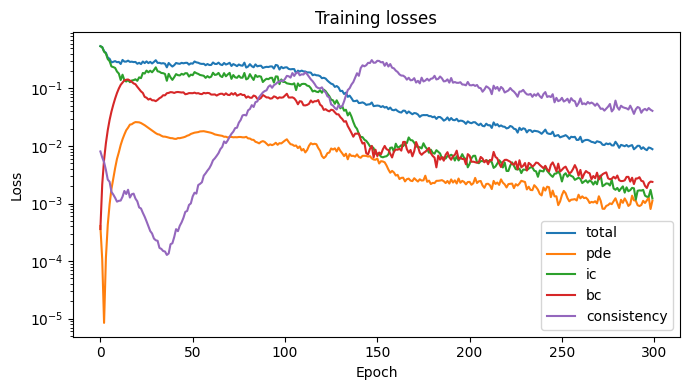

In [37]:

plt.figure(figsize=(7, 4))
for key, values in history_c.items():
    if key == "consistency" and not USE_AUXILIARY_DERIVATIVE:
        continue
    plt.semilogy(values, label=key)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training losses")
plt.tight_layout()
plt.show()


Training curves quantum

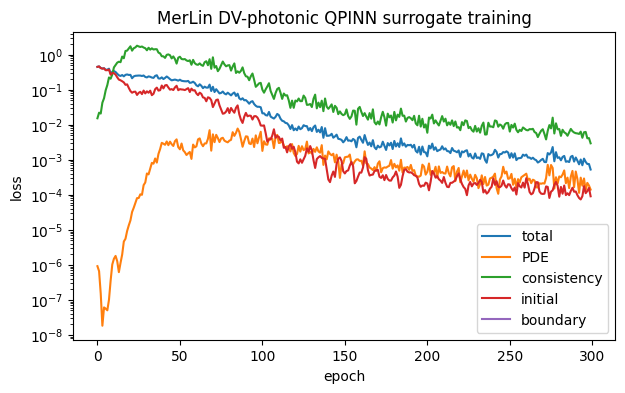

In [38]:
# Plot training losses
hist = np.array(history)
plt.figure(figsize=(7, 4))
plt.semilogy(hist[:, 0], label="total")
plt.semilogy(hist[:, 1], label="PDE")
plt.semilogy(hist[:, 2], label="consistency")
plt.semilogy(hist[:, 3], label="initial")
plt.semilogy(hist[:, 4], label="boundary")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.title("MerLin DV-photonic QPINN surrogate training")
plt.show()

Classical evaluation on a grid

In [39]:

@torch.no_grad()
def predict_u(model_c, xt):
    if USE_AUXILIARY_DERIVATIVE:
        u, _ = model_c(xt)
        return u
    return model_c(xt)


def evaluate_on_grid(model_c, nx=101, nt=101):
    x = torch.linspace(0, 1, nx, device=DEVICE, dtype=DTYPE).view(-1, 1)
    t = torch.linspace(0, 1, nt, device=DEVICE, dtype=DTYPE).view(-1, 1)
    X, T = torch.meshgrid(x.squeeze(), t.squeeze(), indexing="ij")
    xt = torch.stack([X.reshape(-1), T.reshape(-1)], dim=1)

    u_pred = predict_u(model_c, xt).reshape(nx, nt)
    u_true = exact_u(X, T)

    rel_l2 = torch.linalg.norm(u_pred - u_true) / torch.linalg.norm(u_true)
    max_abs = torch.max(torch.abs(u_pred - u_true))
    return X.detach().cpu(), T.detach().cpu(), u_pred.detach().cpu(), u_true.detach().cpu(), rel_l2.item(), max_abs.item()


X, T, U_pred, U_true, rel_l2, max_abs = evaluate_on_grid(model_c)
print(f"Relative L2 error: {rel_l2:.4e}")
print(f"Max absolute error: {max_abs:.4e}")


Relative L2 error: 5.0214e-02
Max absolute error: 9.4558e-02


Plots classical

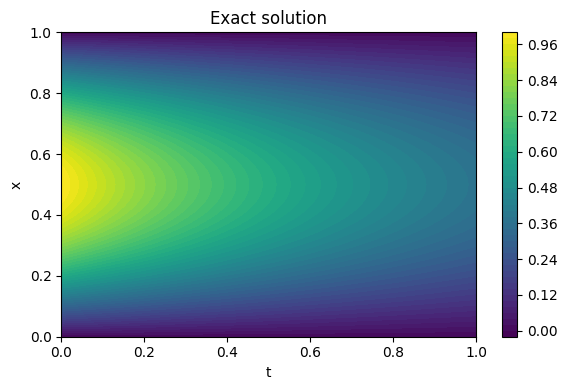

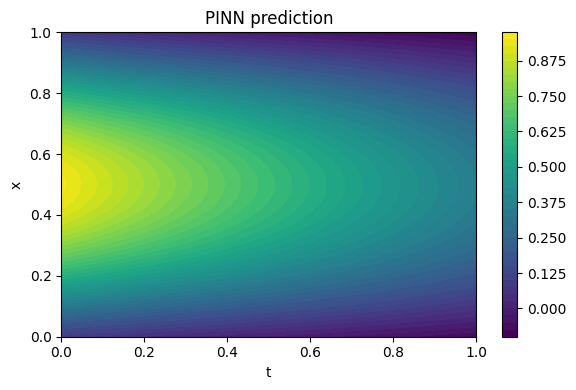

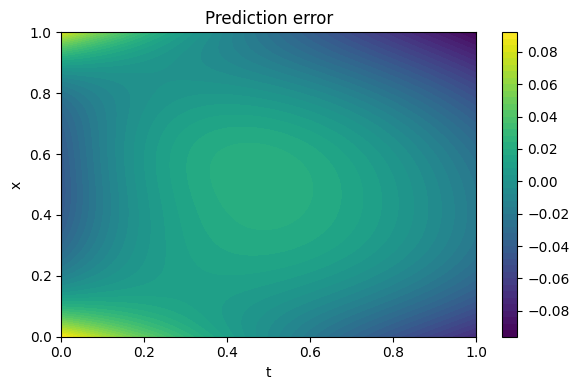

In [40]:

plt.figure(figsize=(6, 4))
plt.contourf(T.numpy(), X.numpy(), U_true.numpy(), levels=50)
plt.xlabel("t")
plt.ylabel("x")
plt.title("Exact solution")
plt.colorbar()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.contourf(T.numpy(), X.numpy(), U_pred.numpy(), levels=50)
plt.xlabel("t")
plt.ylabel("x")
plt.title("PINN prediction")
plt.colorbar()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.contourf(T.numpy(), X.numpy(), (U_pred - U_true).numpy(), levels=50)
plt.xlabel("t")
plt.ylabel("x")
plt.title("Prediction error")
plt.colorbar()
plt.tight_layout()
plt.show()


Evaluation and Plots for quantum

relative L2 error: 0.01814354956150055


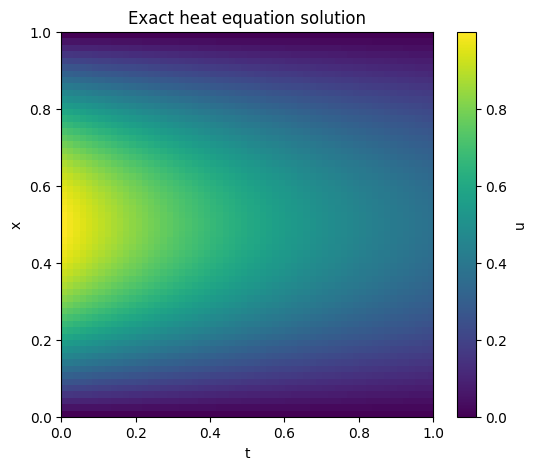

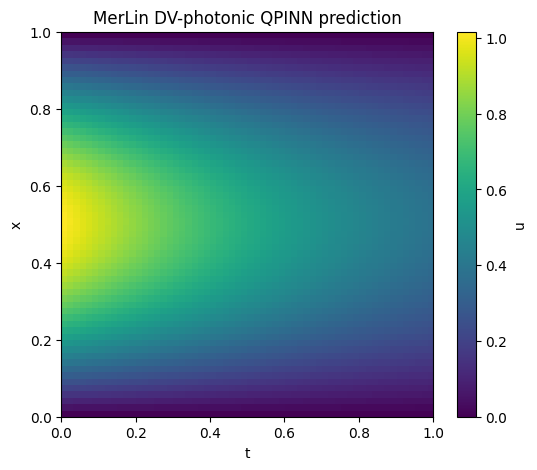

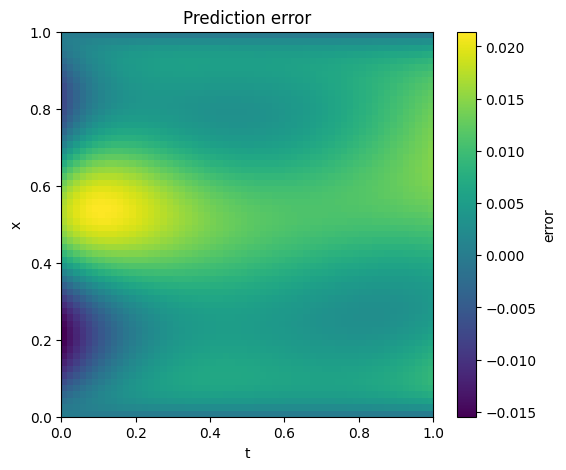

In [41]:
# Evaluate on a grid
nx, nt = 60, 60
x = torch.linspace(0, 1, nx, device=device, dtype=dtype).reshape(-1, 1)
t = torch.linspace(0, 1, nt, device=device, dtype=dtype).reshape(-1, 1)
X, T = torch.meshgrid(x.squeeze(), t.squeeze(), indexing="ij")
xt_grid = torch.stack([X.reshape(-1), T.reshape(-1)], dim=1)

with torch.no_grad():
    U_pred, UX_hat = model(xt_grid)
    U_pred = U_pred.reshape(nx, nt).cpu()
    U_true = exact_u(xt_grid[:, 0:1], xt_grid[:, 1:2]).reshape(nx, nt).cpu()

rel_l2 = torch.linalg.norm(U_pred - U_true) / torch.linalg.norm(U_true)
print("relative L2 error:", float(rel_l2))

# Visual comparison
plt.figure(figsize=(6, 5))
plt.imshow(U_true.numpy(), origin="lower", extent=[0, 1, 0, 1], aspect="auto")
plt.colorbar(label="u")
plt.xlabel("t")
plt.ylabel("x")
plt.title("Exact heat equation solution")
plt.show()

plt.figure(figsize=(6, 5))
plt.imshow(U_pred.numpy(), origin="lower", extent=[0, 1, 0, 1], aspect="auto")
plt.colorbar(label="u")
plt.xlabel("t")
plt.ylabel("x")
plt.title("MerLin DV-photonic QPINN prediction")
plt.show()

plt.figure(figsize=(6, 5))
plt.imshow((U_pred - U_true).numpy(), origin="lower", extent=[0, 1, 0, 1], aspect="auto")
plt.colorbar(label="error")
plt.xlabel("t")
plt.ylabel("x")
plt.title("Prediction error")
plt.show()

Classical vs Quantum comparison

In [42]:
@torch.no_grad()
def evaluate_model_l2(model, exact_fn, nx=60, nt=60, device=None, dtype=None):
    x = torch.linspace(0, 1, nx, device=device, dtype=dtype).reshape(-1, 1)
    t = torch.linspace(0, 1, nt, device=device, dtype=dtype).reshape(-1, 1)
    X, T = torch.meshgrid(x.squeeze(), t.squeeze(), indexing="ij")
    xt = torch.stack([X.reshape(-1), T.reshape(-1)], dim=1)
    y = model(xt)
    if isinstance(y, tuple) or isinstance(y, list):
        y = y[0]
    y = y.reshape(nx, nt).cpu()
    u_true = exact_fn(xt[:, 0:1], xt[:, 1:2]).reshape(nx, nt).cpu()
    rel_l2 = torch.linalg.norm(y - u_true) / torch.linalg.norm(u_true)
    max_abs = torch.max(torch.abs(y - u_true))
    return rel_l2.item(), max_abs.item()

classical_rel_l2, classical_max_abs = evaluate_model_l2(model_c, exact_u_c, nx=60, nt=60, device=DEVICE, dtype=DTYPE)
quantum_rel_l2, quantum_max_abs = evaluate_model_l2(model, exact_u, nx=60, nt=60, device=device, dtype=dtype)

classical_final_total = history_c["total"][-1] if len(history_c["total"]) else float("nan")
classical_final_pde = history_c["pde"][-1] if len(history_c["pde"]) else float("nan")
classical_final_ic = history_c["ic"][-1] if len(history_c["ic"]) else float("nan")
classical_final_bc = history_c["bc"][-1] if len(history_c["bc"]) else float("nan")
classical_final_consistency = history_c["consistency"][-1] if len(history_c["consistency"]) else float("nan")

quantum_final_total = history[-1][0] if len(history) else float("nan")
quantum_final_pde = history[-1][1] if len(history) else float("nan")
quantum_final_consistency = history[-1][2] if len(history) else float("nan")
quantum_final_ic = history[-1][3] if len(history) else float("nan")
quantum_final_bc = history[-1][4] if len(history) else float("nan")

classical_time = globals().get("elapsed", None)
quantum_time = globals().get("elapsed_q", None)

print("=== Classical vs Quantum summary ===")
print(f"Classical relative L2 error: {classical_rel_l2:.4e}")
print(f"Quantum   relative L2 error: {quantum_rel_l2:.4e}")
print(f"Classical max abs error:   {classical_max_abs:.4e}")
print(f"Quantum   max abs error:   {quantum_max_abs:.4e}")
print()
print(f"Classical final total loss:       {classical_final_total:.4e}")
print(f"Classical final PDE loss:         {classical_final_pde:.4e}")
print(f"Classical final IC loss:          {classical_final_ic:.4e}")
print(f"Classical final BC loss:          {classical_final_bc:.4e}")
print(f"Classical final consistency loss: {classical_final_consistency:.4e}")
print()
print(f"Quantum final total loss:         {quantum_final_total:.4e}")
print(f"Quantum final PDE loss:           {quantum_final_pde:.4e}")
print(f"Quantum final consistency loss:   {quantum_final_consistency:.4e}")
print(f"Quantum final IC loss:            {quantum_final_ic:.4e}")
print(f"Quantum final BC loss:            {quantum_final_bc:.4e}")
print()
if classical_time is not None:
    print(f"Classical training time: {classical_time:.2f} s")
else:
    print("Classical training time: not recorded in this notebook run")
if quantum_time is not None:
    print(f"Quantum training time: {quantum_time:.2f} s")
else:
    print("Quantum training time: not recorded in this notebook run")

=== Classical vs Quantum summary ===
Classical relative L2 error: 5.1370e-02
Quantum   relative L2 error: 1.8144e-02
Classical max abs error:   9.4558e-02
Quantum   max abs error:   2.1409e-02

Classical final total loss:       8.7993e-03
Classical final PDE loss:         1.1191e-03
Classical final IC loss:          1.2259e-03
Classical final BC loss:          2.3776e-03
Classical final consistency loss: 4.0766e-02

Quantum final total loss:         5.3008e-04
Quantum final PDE loss:           1.4179e-04
Quantum final consistency loss:   2.9705e-03
Quantum final IC loss:            9.1244e-05
Quantum final BC loss:            0.0000e+00

Classical training time: not recorded in this notebook run
Quantum training time: not recorded in this notebook run


Try different parameters:

Parameter sweep: Quantum feature and output size sensitivity

In [ ]:

# Parameter sweep over quantum_feature_size and quantum_output_size (kept equal)
# With multiple seeds for robust statistics
sizes = list(range(4, 17, 4))  # 4, 6, 8, 10, 12
num_seeds = 2

# Store results: mean and std for each size
errors_rel_l2_mean = []
errors_rel_l2_std = []
errors_max_abs_mean = []
errors_max_abs_std = []
computation_times_mean = []
computation_times_std = []

sweep_epochs = 150  # Use fewer epochs for faster sweep
base_seed = 42

print("Starting parameter sweep where feature_size == output_size...")
print(f"Sizes to test: {sizes}")
print(f"Number of seeds per size: {num_seeds}")

for size in sizes:
    print(f"\n{'='*60}")
    print(f"Testing feature_size={size}, output_size={size}")
    print(f"{'='*60}")
    
    # Storage for this size across different seeds
    size_errors_rel_l2 = []
    size_errors_max_abs = []
    size_computation_times = []
    
    for seed_idx in range(num_seeds):
        current_seed = base_seed + seed_idx
        print(f"\n  Seed {seed_idx + 1}/{num_seeds} (seed={current_seed})")
        
        # Set seeds for reproducibility
        torch.manual_seed(current_seed)
        np.random.seed(current_seed)
        random.seed(current_seed)
        
        # Start timer
        start_time = time.time()
        
        # Create model with current feature and output sizes (equal)
        sweep_model = MerlinHeatQPINN(
            feature_size=size,
            quantum_output_size=size,
            hidden=quantum_hidden,
        ).to(device=device, dtype=dtype)
        
        # Align dtypes
        for p in sweep_model.parameters():
            if p.is_floating_point():
                p.data = p.data.to(dtype)
        
        sweep_optimizer = torch.optim.Adam(sweep_model.parameters(), lr=lr)
        
        # Quick training
        for epoch in range(1, sweep_epochs + 1):
            sweep_optimizer.zero_grad()
            
            xt_f = sample_interior(n_f)
            xt_i = sample_initial(n_i)
            xt_b = sample_boundary(n_b)
            
            r_f, r_c = pde_and_consistency_residuals(sweep_model, xt_f)
            loss_f = mse(r_f, torch.zeros_like(r_f))
            loss_c = mse(r_c, torch.zeros_like(r_c))
            
            u_i, _ = sweep_model(xt_i)
            x_i = xt_i[:, 0:1]
            t_i = xt_i[:, 1:2]
            loss_i = mse(u_i, exact_u(x_i, t_i))
            
            u_b, _ = sweep_model(xt_b)
            loss_b = mse(u_b, torch.zeros_like(u_b))
            
            loss = lambda_f * loss_f + lambda_c * loss_c + lambda_i * loss_i + lambda_b * loss_b
            loss.backward()
            sweep_optimizer.step()
            
            if epoch % 50 == 0 or epoch == 1:
                print(f"    Epoch {epoch}: loss={loss.item():.4e}")
        
        # Evaluate on grid
        nx, nt = 40, 40
        x = torch.linspace(0, 1, nx, device=device, dtype=dtype).reshape(-1, 1)
        t = torch.linspace(0, 1, nt, device=device, dtype=dtype).reshape(-1, 1)
        X, T = torch.meshgrid(x.squeeze(), t.squeeze(), indexing="ij")
        xt_grid = torch.stack([X.reshape(-1), T.reshape(-1)], dim=1)
        
        with torch.no_grad():
            U_pred, _ = sweep_model(xt_grid)
            U_pred = U_pred.reshape(nx, nt).cpu()
            U_true = exact_u(xt_grid[:, 0:1], xt_grid[:, 1:2]).reshape(nx, nt).cpu()
        
        rel_l2 = torch.linalg.norm(U_pred - U_true) / torch.linalg.norm(U_true)
        max_abs = torch.max(torch.abs(U_pred - U_true))
        
        # Record elapsed time
        elapsed = time.time() - start_time
        
        size_errors_rel_l2.append(rel_l2.item())
        size_errors_max_abs.append(max_abs.item())
        size_computation_times.append(elapsed)
        
        print(f"    Rel L2 error: {rel_l2.item():.4e}, Max abs error: {max_abs.item():.4e}")
        print(f"    Computation time: {elapsed:.2f} s")
    
    # Compute mean and std for this size
    mean_rel_l2 = np.mean(size_errors_rel_l2)
    std_rel_l2 = np.std(size_errors_rel_l2)
    mean_max_abs = np.mean(size_errors_max_abs)
    std_max_abs = np.std(size_errors_max_abs)
    mean_time = np.mean(size_computation_times)
    std_time = np.std(size_computation_times)
    
    errors_rel_l2_mean.append(mean_rel_l2)
    errors_rel_l2_std.append(std_rel_l2)
    errors_max_abs_mean.append(mean_max_abs)
    errors_max_abs_std.append(std_max_abs)
    computation_times_mean.append(mean_time)
    computation_times_std.append(std_time)
    
    print(f"\n  Summary for size={size}:")
    print(f"    Rel L2: {mean_rel_l2:.4e} ± {std_rel_l2:.4e}")
    print(f"    Max abs: {mean_max_abs:.4e} ± {std_max_abs:.4e}")
    print(f"    Time: {mean_time:.2f} ± {std_time:.2f} s")

print("\n" + "="*60)
print("=== Parameter Sweep Results (Mean ± Std) ===")
print("="*60)
for size, m_l2, s_l2, m_max, s_max, m_t, s_t in zip(sizes, errors_rel_l2_mean, errors_rel_l2_std, 
                                                       errors_max_abs_mean, errors_max_abs_std,
                                                       computation_times_mean, computation_times_std):
    print(f"size={size:2d}: rel_L2={m_l2:.4e}±{s_l2:.4e}, max_abs={m_max:.4e}±{s_max:.4e}, time={m_t:.2f}±{s_t:.2f}s")

# Create x-y plots with error bars
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot relative L2 error with error bars
ax1 = axes[0, 0]
ax1.errorbar(sizes, errors_rel_l2_mean, yerr=errors_rel_l2_std, fmt='o-', linewidth=2, markersize=8, 
             capsize=5, capthick=2, color='blue', ecolor='blue', alpha=0.7, label='Mean ± Std')
ax1.set_xlabel('Quantum Feature/Output Size')
ax1.set_ylabel('Relative L2 Error')
ax1.set_title('Relative L2 Error vs Feature/Output Size')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Plot max absolute error with error bars
ax2 = axes[0, 1]
ax2.errorbar(sizes, errors_max_abs_mean, yerr=errors_max_abs_std, fmt='s-', linewidth=2, markersize=8,
             capsize=5, capthick=2, color='orange', ecolor='orange', alpha=0.7, label='Mean ± Std')
ax2.set_xlabel('Quantum Feature/Output Size')
ax2.set_ylabel('Max Absolute Error')
ax2.set_title('Max Absolute Error vs Feature/Output Size')
ax2.grid(True, alpha=0.3)
ax2.legend()

# Plot computation time with error bars
ax3 = axes[1, 0]
ax3.errorbar(sizes, computation_times_mean, yerr=computation_times_std, fmt='^-', linewidth=2, markersize=8,
             capsize=5, capthick=2, color='green', ecolor='green', alpha=0.7, label='Mean ± Std')
ax3.set_xlabel('Quantum Feature/Output Size')
ax3.set_ylabel('Computation Time (s)')
ax3.set_title('Computation Time vs Feature/Output Size')
ax3.grid(True, alpha=0.3)
ax3.legend()

# Plot error vs time (scatter with error bars)
ax4 = axes[1, 1]
ax4.errorbar(computation_times_mean, errors_rel_l2_mean, xerr=computation_times_std, yerr=errors_rel_l2_std,
             fmt='o', markersize=8, capsize=5, capthick=2, color='blue', ecolor='blue', alpha=0.6, label='Rel L2 Error')
ax4.errorbar(computation_times_mean, errors_max_abs_mean, xerr=computation_times_std, yerr=errors_max_abs_std,
             fmt='s', markersize=8, capsize=5, capthick=2, color='orange', ecolor='orange', alpha=0.6, label='Max Abs Error')
ax4.set_xlabel('Computation Time (s)')
ax4.set_ylabel('Error')
ax4.set_title('Error vs Computation Time')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nBest configurations (by mean):")
min_l2_idx = np.argmin(errors_rel_l2_mean)
min_max_idx = np.argmin(errors_max_abs_mean)
print(f"Best L2 error: size={sizes[min_l2_idx]}, error={errors_rel_l2_mean[min_l2_idx]:.4e}±{errors_rel_l2_std[min_l2_idx]:.4e}, time={computation_times_mean[min_l2_idx]:.2f}s")
print(f"Best max abs error: size={sizes[min_max_idx]}, error={errors_max_abs_mean[min_max_idx]:.4e}±{errors_max_abs_std[min_max_idx]:.4e}, time={computation_times_mean[min_max_idx]:.2f}s")
print(f"\nTotal sweep time: {sum(computation_times_mean):.2f}s (±{np.std(computation_times_mean):.2f}s)")


Starting parameter sweep where feature_size == output_size...
Sizes to test: [4, 8, 12, 16]
Number of seeds per size: 2

Testing feature_size=4, output_size=4

  Seed 1/2 (seed=42)
    Epoch 1: loss=5.0933e-01
    Epoch 50: loss=1.2677e-01
    Epoch 100: loss=1.2549e-02
    Epoch 150: loss=3.8737e-03
    Rel L2 error: 3.1950e-02, Max abs error: 4.1066e-02
    Computation time: 28.74 s

  Seed 2/2 (seed=43)
    Epoch 1: loss=4.4244e-01
    Epoch 50: loss=1.3874e-01
    Epoch 100: loss=1.3672e-02
    Epoch 150: loss=4.5014e-03
    Rel L2 error: 2.7472e-02, Max abs error: 3.0169e-02
    Computation time: 27.64 s

  Summary for size=4:
    Rel L2: 2.9711e-02 ± 2.2393e-03
    Max abs: 3.5617e-02 ± 5.4483e-03
    Time: 28.19 ± 0.55 s

Testing feature_size=8, output_size=8

  Seed 1/2 (seed=42)
    Epoch 1: loss=4.9719e-01
    Epoch 50: loss=1.9058e-01
    Epoch 100: loss=7.9390e-02
    Epoch 150: loss=1.2010e-02
    Rel L2 error: 4.5747e-02, Max abs error: 4.5272e-02
    Computation time: 11

In [ ]:
# Seed sensitivity sweep at low feature/output size
seed_sweep_size = 4
seed_values = list(range(100, 120))  # 20 different seeds
sweep_epochs = 100

seed_errors_rel_l2 = []
seed_errors_max_abs = []
seed_times = []

print(f"Running seed sweep for size={seed_sweep_size}, {len(seed_values)} seeds...")
for seed_idx, seed_val in enumerate(seed_values, start=1):
    print(f"\nSeed {seed_idx}/{len(seed_values)}: seed={seed_val}")
    torch.manual_seed(seed_val)
    np.random.seed(seed_val)
    random.seed(seed_val)

    start_time = time.time()
    
    sweep_model = MerlinHeatQPINN(
        feature_size=seed_sweep_size,
        quantum_output_size=seed_sweep_size,
        hidden=quantum_hidden,
    ).to(device=device, dtype=dtype)
    
    for p in sweep_model.parameters():
        if p.is_floating_point():
            p.data = p.data.to(dtype)

    sweep_optimizer = torch.optim.Adam(sweep_model.parameters(), lr=lr)

    for epoch in range(1, sweep_epochs + 1):
        sweep_optimizer.zero_grad()

        xt_f = sample_interior(n_f)
        xt_i = sample_initial(n_i)
        xt_b = sample_boundary(n_b)

        r_f, r_c = pde_and_consistency_residuals(sweep_model, xt_f)
        loss_f = mse(r_f, torch.zeros_like(r_f))
        loss_c = mse(r_c, torch.zeros_like(r_c))

        u_i, _ = sweep_model(xt_i)
        x_i = xt_i[:, 0:1]
        t_i = xt_i[:, 1:2]
        loss_i = mse(u_i, exact_u(x_i, t_i))

        u_b, _ = sweep_model(xt_b)
        loss_b = mse(u_b, torch.zeros_like(u_b))

        loss = lambda_f * loss_f + lambda_c * loss_c + lambda_i * loss_i + lambda_b * loss_b
        loss.backward()
        sweep_optimizer.step()

        if epoch == 1 or epoch % 50 == 0:
            print(f"  Epoch {epoch}: loss={loss.item():.4e}")

    nx, nt = 40, 40
    x = torch.linspace(0, 1, nx, device=device, dtype=dtype).reshape(-1, 1)
    t = torch.linspace(0, 1, nt, device=device, dtype=dtype).reshape(-1, 1)
    X, T = torch.meshgrid(x.squeeze(), t.squeeze(), indexing="ij")
    xt_grid = torch.stack([X.reshape(-1), T.reshape(-1)], dim=1)

    with torch.no_grad():
        U_pred, _ = sweep_model(xt_grid)
        U_pred = U_pred.reshape(nx, nt).cpu()
        U_true = exact_u(xt_grid[:, 0:1], xt_grid[:, 1:2]).reshape(nx, nt).cpu()

    rel_l2 = torch.linalg.norm(U_pred - U_true) / torch.linalg.norm(U_true)
    max_abs = torch.max(torch.abs(U_pred - U_true))
    elapsed = time.time() - start_time

    seed_errors_rel_l2.append(rel_l2.item())
    seed_errors_max_abs.append(max_abs.item())
    seed_times.append(elapsed)

    print(f"  rel_L2={rel_l2.item():.4e}, max_abs={max_abs.item():.4e}, time={elapsed:.2f}s")

best_rel_idx = int(np.argmin(seed_errors_rel_l2))
best_max_idx = int(np.argmin(seed_errors_max_abs))
print(f"\nBest seed by rel_L2: seed={seed_values[best_rel_idx]}, rel_L2={seed_errors_rel_l2[best_rel_idx]:.4e}")
print(f"Best seed by max_abs: seed={seed_values[best_max_idx]}, max_abs={seed_errors_max_abs[best_max_idx]:.4e}")

plt.figure(figsize=(10, 4))
plt.plot(seed_values, seed_errors_rel_l2, 'o-', label='Relative L2 Error')
plt.plot(seed_values, seed_errors_max_abs, 's-', label='Max Absolute Error')
plt.xlabel('Seed')
plt.ylabel('Error')
plt.title(f'Seed sensitivity for feature/output size={seed_sweep_size}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(seed_values, seed_times, '^-', color='green')
plt.xlabel('Seed')
plt.ylabel('Computation Time (s)')
plt.title(f'Computation time across seeds for size={seed_sweep_size}')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
